# **Project 2: Model Comparison (Phase 2, Forest Cover Type Classification)**

David Almona \
DSC 340: Applied Machine Learning \
Spring 2026

---

**Dataset:** Forest Cover Type (30,000 rows, 54 features, 7-class classification) 

**Metric:** Macro F1 score

**Task:**  Predict the forest cover type (one of 7 tree species) from 54 features: 10 continuous variables and 44 binary indicators.



**Sections:**

01. Import Libraries
02. Data Loading and Brief EDA
03. Train/Test Split
04. Five-Model Pipeline
05. Results Table
06. Verdict
07. References and Acknowledgments

## 01. Import Libraries

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

## 02. Load Data & Exploratory Data Analysis

- ~~Class distribution (bar chart with percentages).~~ Discuss the imbalance.
- Feature characterization: describe the three feature groups (continuous, wilderness, soil). Identify sparse soil types.
- At least one interaction analysis (e.g., how does elevation distribution differ across
wilderness areas or cover types?).
- ~~Correlation matrix for continuous features.~~ Flag any strong correlations.

In [ ]:
df = pd.read_csv('covtype_30k.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2728,63,3,182,12,1320,222,233,146,1947,...,0,0,0,0,0,0,0,0,0,2
1,3212,176,10,339,13,3316,225,246,152,451,...,0,0,0,0,0,0,0,0,0,2
2,3217,196,17,771,3,446,213,252,167,2523,...,0,0,0,0,0,0,0,0,0,2
3,2897,93,22,256,92,2684,248,200,70,1273,...,0,0,0,0,0,0,0,0,0,2
4,3044,47,12,582,190,6423,224,214,122,3829,...,0,0,0,0,0,0,0,0,0,2


In [119]:
# Check dataset dimensions and data types
print(f"Shape: {df.shape}")
print()
print(f"Data types:\n{df.dtypes}")

Shape: (30000, 55)

Data types:
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64


In [120]:
df.describe().round(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,2959.71,155.22,14.07,270.72,46.87,2356.56,212.27,223.37,142.47,1981.30,...,0.09,0.08,0.00,0.00,0.00,0.00,0.02,0.02,0.02,2.05
std,279.06,111.70,7.51,212.79,58.57,1560.68,26.77,19.65,38.14,1326.48,...,0.29,0.27,0.06,0.06,0.02,0.02,0.16,0.15,0.12,1.40
min,1876.00,0.00,0.00,0.00,-152.00,0.00,0.00,87.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,2809.00,58.00,9.00,108.00,7.00,1106.75,199.00,213.00,119.00,1022.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,2996.00,127.00,13.00,218.00,30.00,2012.00,218.00,226.00,143.00,1711.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
75%,3164.00,260.00,18.00,390.00,69.00,3331.00,231.00,237.00,168.00,2550.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
max,3856.00,360.00,51.00,1397.00,550.00,7039.00,254.00,254.00,252.00,7141.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,7.00


Class Distribution (Raw):
 Cover_Type
1    10938
2    14628
3     1846
4      142
5      490
6      897
7     1059
Name: count, dtype: int64

Class Distribution (Proportion):


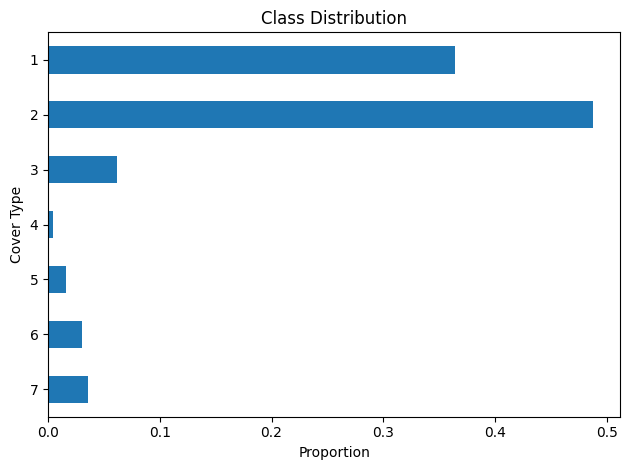

In [ ]:
# class distribution
target_col = df.columns[-1]
class_counts = df[target_col].value_counts().sort_index(ascending = True)

print("Class Distribution (Raw):\n", class_counts)
print()

class_counts = df[target_col].value_counts(normalize = True).sort_index(ascending = False)


print("Class Distribution (Proportion):")
class_counts.plot(kind = 'barh')
plt.title('Class Distribution')
plt.ylabel('Cover Type')
plt.xlabel('Proportion')
plt.xticks(rotation = 0) 
plt.tight_layout()
plt.show()

# discuss the imbalance:
# Cover_Type 1 & 2 significantly more than the others; Cover_Type 4 have the lowest in number
# It is important to remember to use stratified sampling when running classifiers, or else the classifiers will not perform well.

In [ ]:
## correlation matrix for continuous features
# Soil_Type15 contains all zero so it gets filtered out, manually adding it back

binary_cols = [col for col in df.columns if df[col].nunique() == 2]
continuous_cols = [col for col in df.columns if col not in binary_cols]

binary_df = df[binary_cols + ["Soil_Type15"]]
continuous_df = df.drop(columns = [*binary_cols, "Soil_Type15"])

matrix = continuous_df.drop(columns = target_col).corr()
mask = np.triu(np.ones_like(matrix, dtype = bool), k = 1)

plt.figure(figsize = (8,6))
sns.heatmap(matrix, mask = mask, annot = True, cmap = "coolwarm_r", fmt = ".2f", linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.show()

# observations:
# Hillside_9am-Hillside_3pm strong negative correlation
# Aspect-Hillside_3pm strong positive correlation
# ...
# ...

In [ ]:
print(df.columns.to_list)

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type', 'Wilderness_Type']


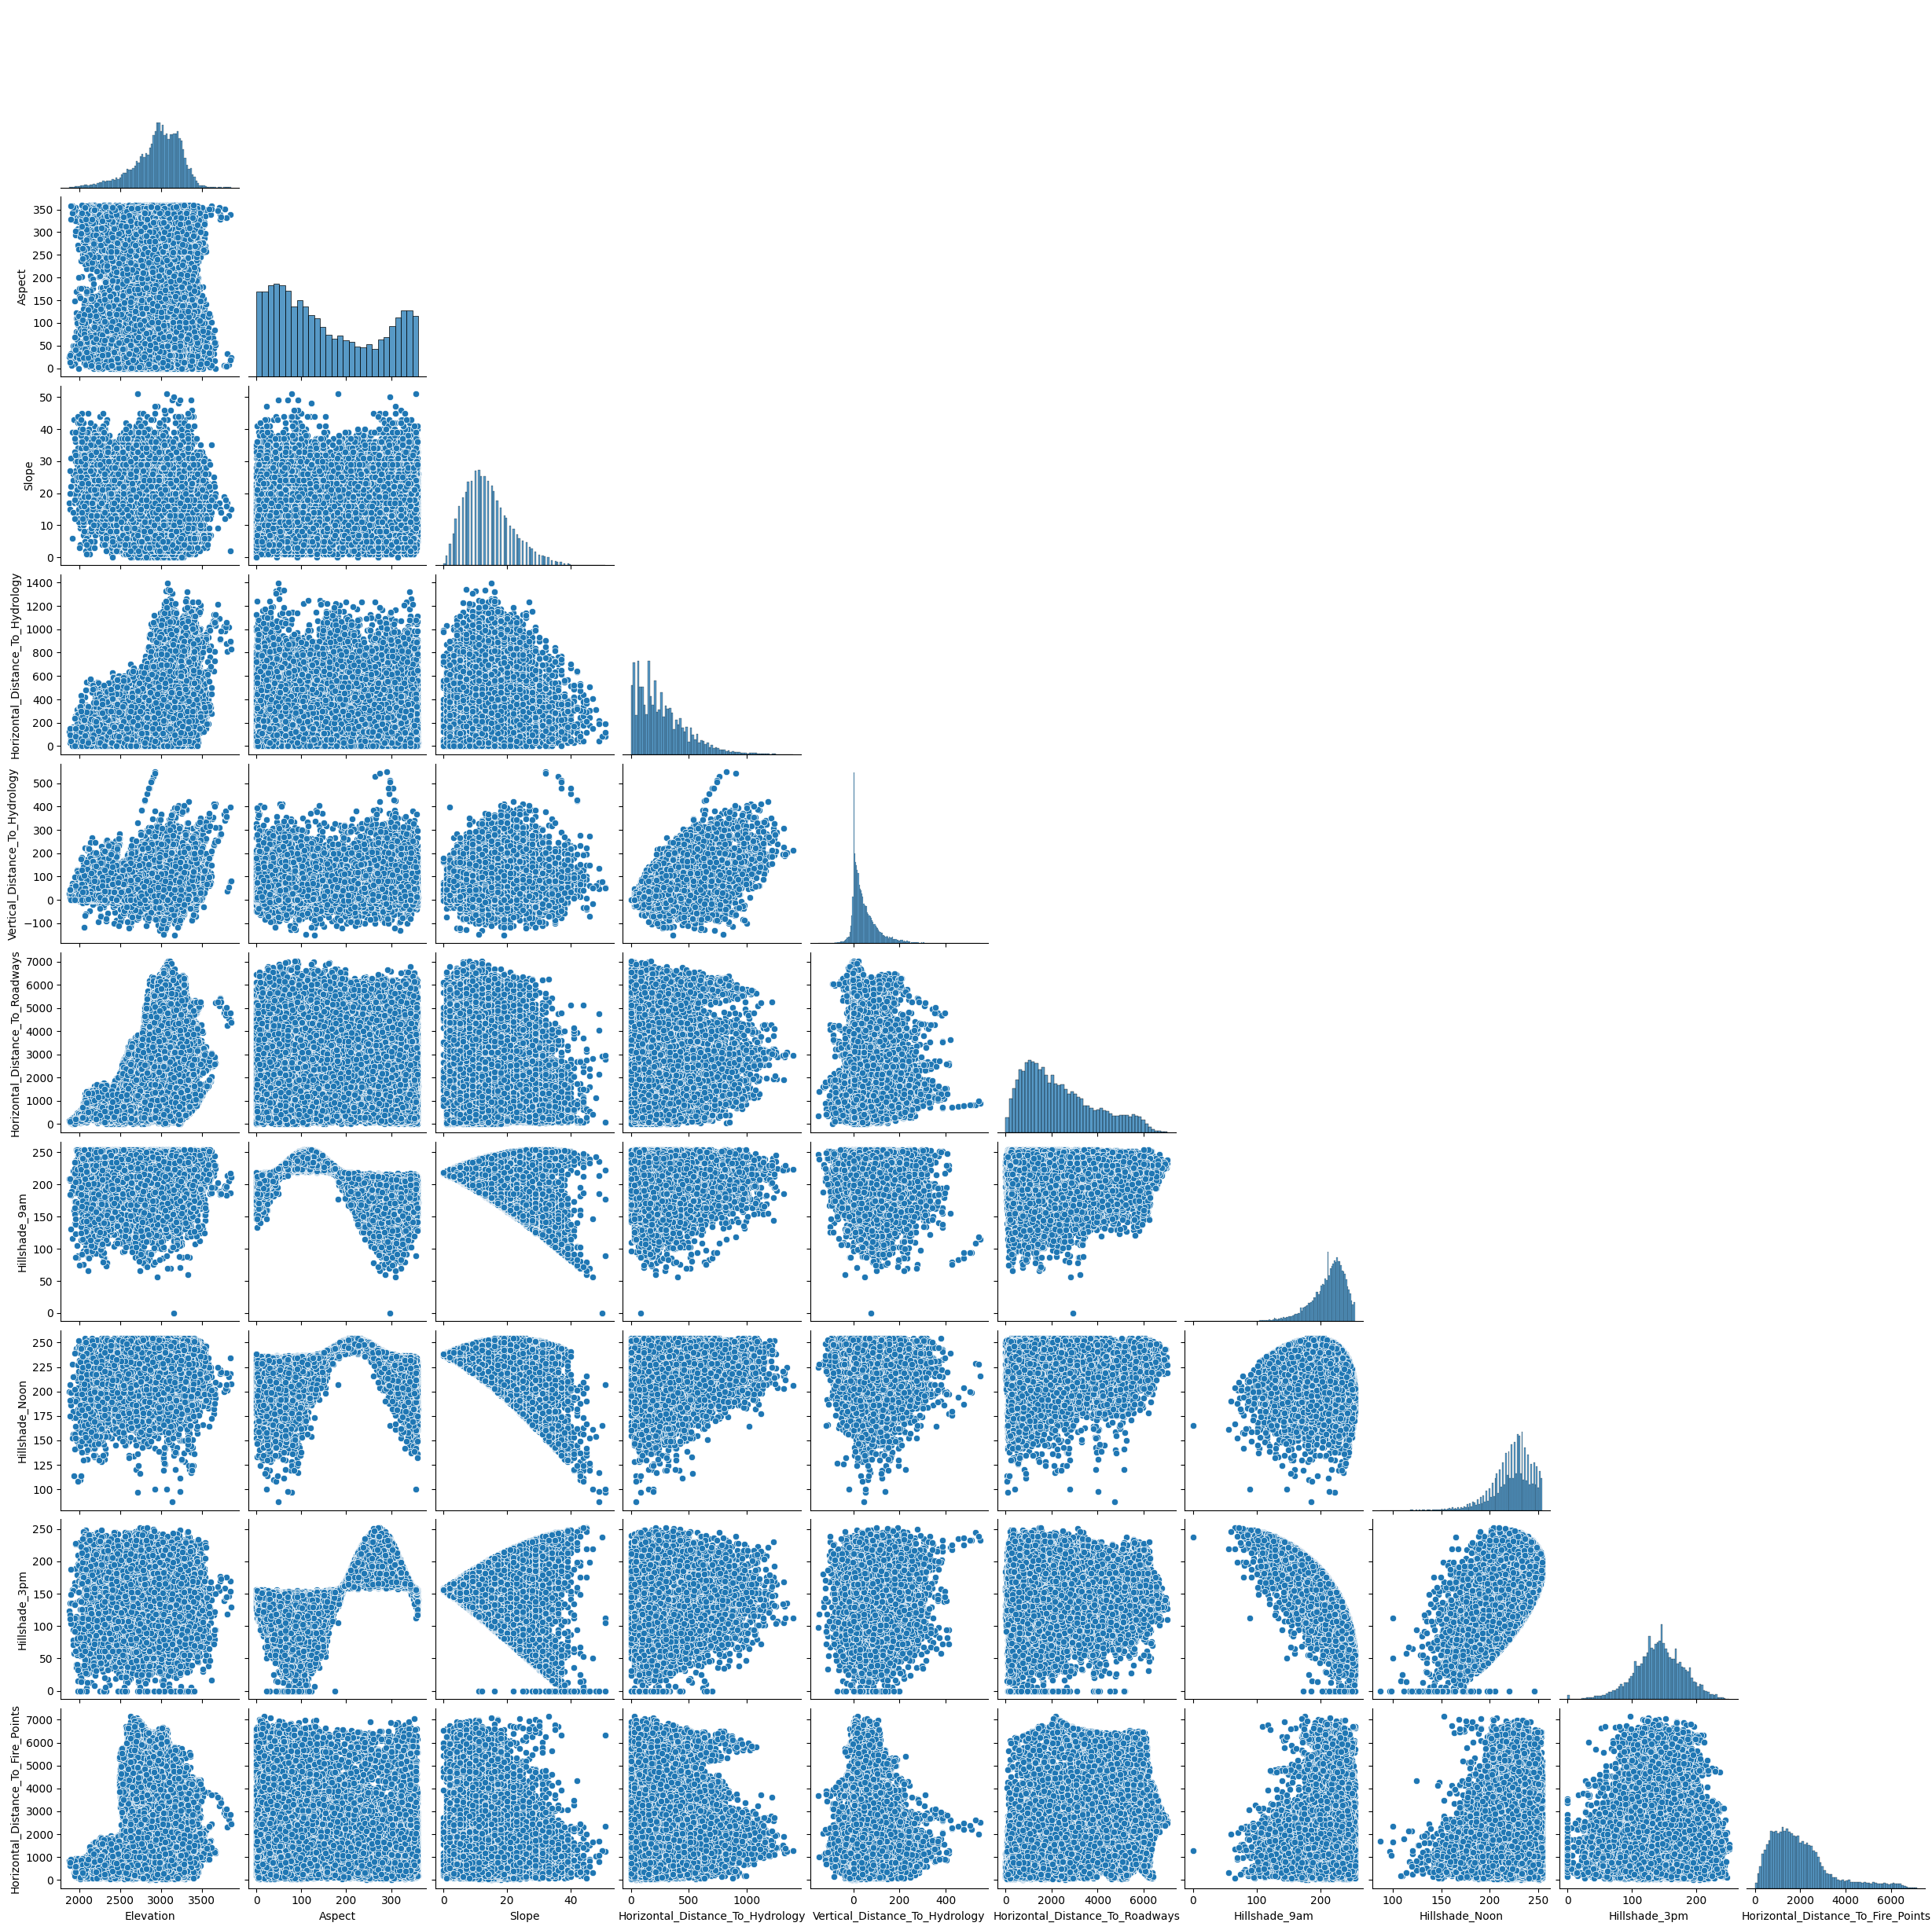

In [ ]:
## Pairplot
sns.pairplot(continuous_df.drop(columns = target_col), corner = True, aspect = 1)

# observations:
# complements the correlation heatmap above
# interesting non linear relationships between `Aspect` and the three `Hillside_` variables
# distance to hydrology variables are heavily skewed towards zero

In [ ]:
## check distribution of Soil_Type

soil_type_df = binary_df.filter(like = 'Soil_Type')
soil_proportions = soil_type_df.mean().round(4).sort_values(ascending = False)*100

prop_table = soil_proportions.reset_index()
prop_table.columns = ['Soil_Type', 'Percentage']

print(prop_table)

# observations:
# Soil_Type29 is ~20% of our data
# 21 Soil_Types with less than 1% (sparse, very very sparse)
# Soil_Type15 with 0.00% (all zeros)

In [ ]:
## check distribution of Wilderness_Area

wilderness_area_df = binary_df.filter(like = 'Wilderness_Area')
wilderness_area_proportions = wilderness_area_df.mean().round(4).sort_values(ascending = False)*100

prop_table = wilderness_area_proportions.reset_index()
prop_table.columns = ['Wilderness_Area', 'Percentage']

print(prop_table)

In [ ]:
## how does elevation distribution differ across wilderness areas

# create a single 'Wilderness_Type' column from the 4 binary columns
wilderness_cols = [col for col in df.columns if 'Wilderness_Area' in col]
df['Wilderness_Type'] = df[wilderness_cols].idxmax(axis = 1)

# KDE Plot
plt.figure(figsize = (10, 6))
sns.kdeplot(data = df, x = 'Elevation', hue = 'Wilderness_Type', fill = True, common_norm = False, palette = 'colorblind')
plt.title('Elevation Distribution by Wilderness Area')
plt.xlabel('Elevation (meters)')
plt.ylabel('Density')
plt.show()

# observation:
# Wilderness_Area4: occupies the low elevations, primarily sitting below 2,500 meters.
# Wilderness_Area2: Concentrated at the highest elevations, with its main peak reaching above 3,200 meters.
# Wilderness_Areas 1 & 3: Show overlap across the middle range.

In [ ]:
## how does elevation distribution differ across cover types

plt.figure(figsize = (14, 10))
sns.boxplot(data = df, x = 'Cover_Type', y = 'Elevation')
plt.title('Elevation Distribution by Cover Type')
plt.xlabel('Cover Type')
plt.show()

# observation:
# Cover Type 7: Occupies the highest elevations, typically above 3,300 meters.
# Cover Type 4: Occupies the lowest elevations, typically below 2,300 meters.
# Cover Types 1 & 2 overlap in the high range, while 3 & 6 overlap in the lower-mid range.

## 03. Feature Engineering

I did just one (1) feature engineering on this dataset, primarily for two reasons:
1. Time constraints
2. Fear that grouping (or binning) continuous variables would cause loss of information

These are some ideas I would have explored:
- Grouping (or binning) sparse `Soil_Type` into an "Other" category
- Grouping (or binning) `Elevation`
- Convert Aspect into categories like "North", "North East", "South", etc

In [ ]:
## Use the Pythagorean theorem to combine `Horizontal_Distance_To_Hydrology` and `Vertical_Distance_To_Hydrology` into a single distance variable.
df['dist_to_hydrology'] = np.hypot(
                            df['Horizontal_Distance_To_Hydrology'],
                            df['Vertical_Distance_To_Hydrology']
                            )

# this reduces the number of features by one, minimal but still helpful with training time.

## 04. Train/test split

80/20 stratified split, `random_state = 42`

In [ ]:
y = df["Cover_Type"]
X = df.drop(columns = ["Cover_Type", "Wilderness_Type", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print(f'Training: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')
print(f'Features: {X_train.shape[1]}')

Training: 24,000  Test: 6,000
Features: 54


## 05. Five-model pipeline

Define a `Pipeline` (scaler + model) and a hyperparameter grid for each of the five classifiers. 

Run `GridSearchCV` with `scoring = 'f1_macro'` and 5-fold `StratifiedKFold`.

Report the best CV macro F1 for each model.

In [ ]:
# define Pipeline and hyperparameter grid for each classifier
# log reg, knn, random forest, svm-rbf, svm-linear

pipelines = {
    'Logistic Regression' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter = 2000, random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.01, 0.1, 1, 10, 100]
        }
    },
    'KNN' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params' : {
            'clf__n_neighbors' : [3, 5, 11, 21, 41],
            'clf__weights' : ['uniform', 'distance']
        }
    },
    'Random Forest' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(random_state = 42))
        ]),
        'params' : {
            'clf__n_estimators' : [100, 300],
            'clf__max_depth' : [None, 10, 20],
            'clf__max_features' : ['sqrt', 'log2']
        }
    },
    'SVM (RBF)' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel = 'rbf', random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.1, 1, 10, 100],
            'clf__gamma' : ['scale', 'auto', 0.01, 0.1]
        }
    },
    'SVM (Linear)' : {
        'pipe' : Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel = 'linear', random_state = 42))
        ]),
        'params' : {
            'clf__C' : [0.001, 0.01, 0.1, 1, 10]
        }
    }
}

In [ ]:
# run grid search with 5-fold stratified CV, scoring on F1
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [ ]:
# Run all five grid searches
results = []

for name, spec in pipelines.items():
    print(f'Running {name}...', end = ' ')
    gs = GridSearchCV(
        spec['pipe'], spec['params'], cv = cv,
        scoring = 'f1_macro', n_jobs = -1, refit = True
    )
    start = time.time()
    gs.fit(X_train, y_train)
    elapsed = time.time() - start
    
    results.append({
        'Model': name,
        'Best CV macro F1': gs.best_score_,
        'Best Params': gs.best_params_,
        'Fit Time (s)': round(elapsed, 1),
        'grid_search': gs  # keep the fitted object for later
    })
    print(f'macro F1 = {gs.best_score_:.4f}  ({elapsed:.1f}s)')

print()
print('Done.')

Running Logistic Regression... F1=0.5349  (37.6s)
Running KNN... F1=0.6950  (27.1s)
Running Random Forest... F1=0.7255  (285.4s)
Running SVM (RBF)... F1=0.7284  (1652.3s)
Running SVM (Linear)... F1=0.5095  (1467.3s)

Done.


## 06. Results Summary
A summary table showing, for each model: best CV macro F1, best hyperparameters, and training time.

A horizontal bar chart comparing macro F1 across models.

In [ ]:
# Results table (without the grid_search objects)
results_df = pd.DataFrame(results).drop(columns = 'grid_search')
results_df = results_df.sort_values('Best CV macro F1', ascending = False)
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = 'Rank'
results_df

,Model,Best CV macro F1,Best Params,Fit Time (s)
Rank,,,,
1,SVM (RBF),0.728405,"{'clf__C': 100, 'clf__gamma': 0.1}",1652.3
2,Random Forest,0.725537,"{'clf__max_depth': None, 'clf__max_features': ...",285.4
3,KNN,0.694980,"{'clf__n_neighbors': 3, 'clf__weights': 'dista...",27.1
4,Logistic Regression,0.534854,{'clf__C': 100},37.6
5,SVM (Linear),0.509539,{'clf__C': 10},1467.3


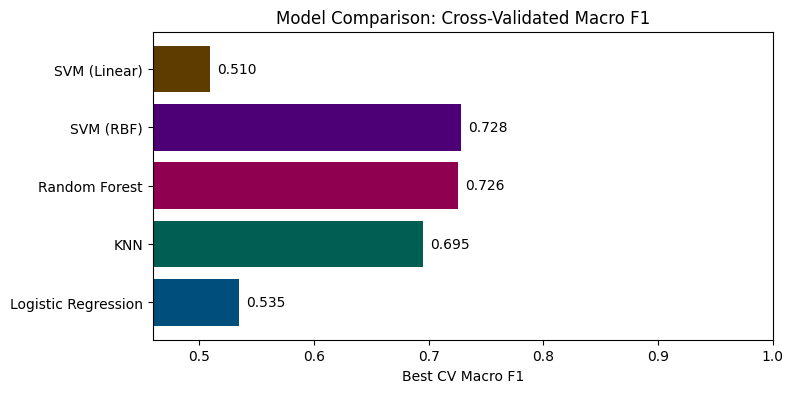

In [ ]:
models = [r['Model'] for r in results]
scores = [r['Best CV macro F1'] for r in results]
colors = ['#004E7C', '#005F52', '#8F0051', '#4D0075', '#5E3C00']

fig, ax = plt.subplots(figsize = (8, 4))
bars = ax.barh(models, scores, color = colors)
ax.bar_label(bars, padding = 5, fmt = '%.3f')
ax.set_xlim(max(0, min(scores) - 0.05), 1.0)

plt.title("Model Comparison: Cross-Validated Macro F1")
plt.xlabel("Best CV Macro F1")

plt.show()

# observation
# top 2 models: SVM-RBF and RF
# only two model fall within one percentage point [SVM-RBF (0.728) and RF (0.726)]
# KNN is 3% away from the top two, while SVM-Linea and Logisitc Regression fall far behind.
# SVM-Linear being the worst model tells us that the dataset has highly non-linear relationship, and 
#     that's also seen in the pairplot above.

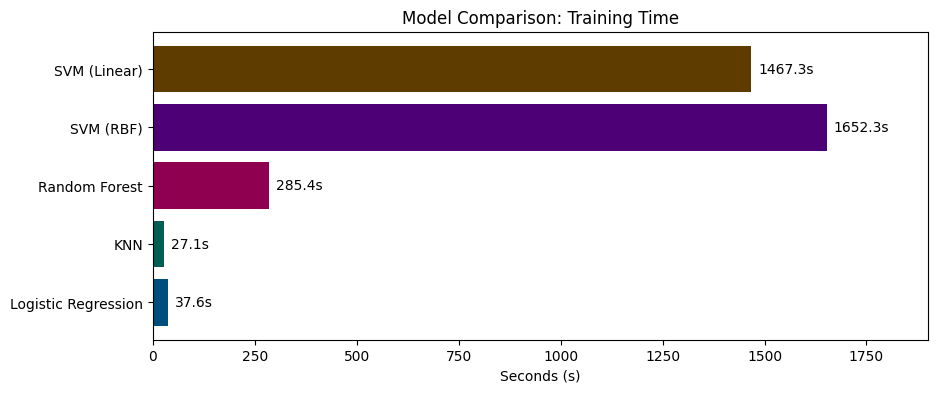

In [ ]:
## computational cost

fig, ax = plt.subplots(figsize = (10, 4))
times = [r['Fit Time (s)'] for r in results]
bars = ax.barh(models, times, color = colors)
ax.bar_label(bars, padding =  5, fmt = '%.1fs')

plt.title("Model Comparison: Training Time")
plt.xlabel("Seconds (s)")
ax.margins(x = 0.15)

plt.show()

## 07. Test-set evaluation


In [ ]:
# a lookup map
gs_map = {r['Model']: r['grid_search'] for r in results}

# get the specific fitted objects
log_gs = gs_map['Logistic Regression']
rf_gs = gs_map['Random Forest']
svm_rbf_gs = gs_map['SVM (RBF)']

In [ ]:
target_models = {
    "Logistic Regression": log_gs,
    "Random Forest": rf_gs,
    "SVM (RBF)": svm_rbf_gs
}

for name, gs in target_models.items():
    print(f"--- {name} Test Evaluation ---")
    start_time = time.time()
    y_pred = gs.predict(X_test)
    total_time = time.time() - start_time
    print(f"Total Batch Time: {total_time:.4f}s")
    print(f"Time per Sample: {total_time / len(X_test):.8f}s")
    print()
    print(classification_report(y_test, y_pred))

--- Logistic Regression Test Evaluation ---
Total Batch Time: 0.0338s
Time per Sample: 0.00000564s
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      2188
           2       0.74      0.80      0.77      2926
           3       0.66      0.75      0.70       369
           4       0.50      0.39      0.44        28
           5       0.00      0.00      0.00        98
           6       0.44      0.25      0.31       179
           7       0.76      0.52      0.62       212

    accuracy                           0.72      6000
   macro avg       0.54      0.49      0.51      6000
weighted avg       0.70      0.72      0.71      6000

--- Random Forest Test Evaluation ---
Total Batch Time: 0.9609s
Time per Sample: 0.00016016s
              precision    recall  f1-score   support

           1       0.86      0.84      0.85      2188
           2       0.85      0.91      0.88      2926
           3       0.80      0.86      0.83     

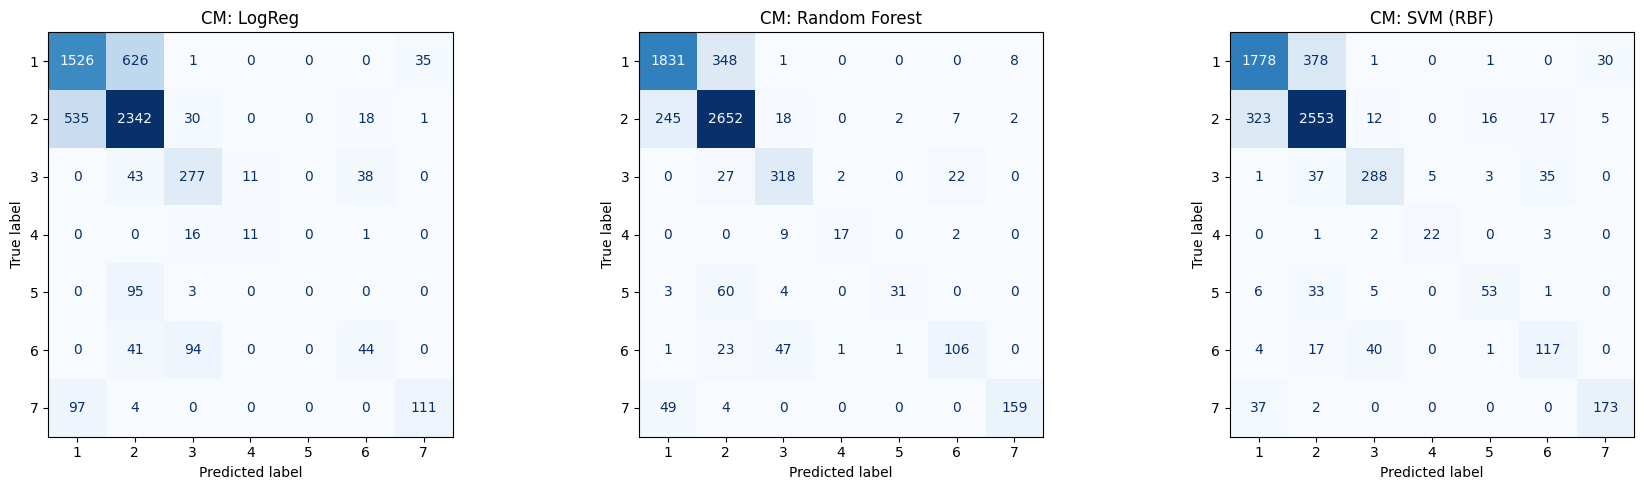

In [ ]:
# confusion matrices

target_names = ['LogReg', 'Random Forest', 'SVM (RBF)']
target_models = [log_gs, rf_gs, svm_rbf_gs]

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, gs, name in zip(axes, target_models, target_names):
    ConfusionMatrixDisplay.from_estimator(
        gs, X_test, y_test, 
        ax = ax, cmap = 'Blues', colorbar = False
    )
    ax.set_title(f"CM: {name}")

plt.tight_layout()
plt.show()

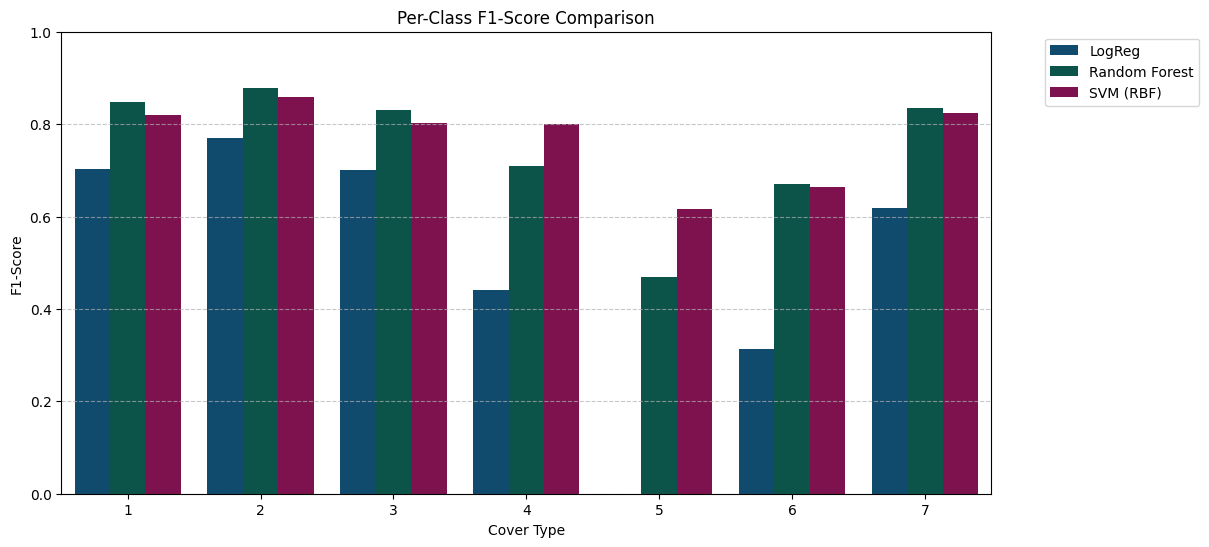

In [ ]:
## Per-Class F1 Comparison (Grouped Bar Chart)

f1_data = []

for name, gs in zip(target_names, target_models):
    # Get report as a dictionary
    report = classification_report(y_test, gs.predict(X_test), output_dict = True)
    
    # Extract F1 for each class
    for class_label in [str(i) for i in range(1, 8)]:
        if class_label in report:
            f1_data.append({
                'Model': name,
                'Cover Type': class_label,
                'F1-Score': report[class_label]['f1-score']
            })

f1_df = pd.DataFrame(f1_data)

plt.figure(figsize = (12, 6))
sns.barplot(data = f1_df, x = 'Cover Type', y = 'F1-Score', hue = 'Model', palette = colors[:3])

plt.title("Per-Class F1-Score Comparison")
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

## 08. Analysis

- **Which classes are hardest?** \
    Cover Type 4 was the rarest class, followed by 5 then 6. For the most part, the rare classes did not get ignored. Logistic Regression is the only model that recorded a zero on the fifth class; SVM (RBF) handled it best, with an F1-score slightly above 0.6.

<br>

- **Accuracy vs. macro F1** \
    Logistic Regression: Accuracy (0.72), Macro F1 (0.51) \
    Random Forest: Accuracy (0.85), Macro F1 (0.75) \
    SVM (RBF): Accuracy (0.83), Macro F1 (0.77) <br>

    Random Forest has a better accuracy score, but SVM (RBF) has a better Macro F1 score. Looking at the grouped bar chart, RF performs better on the majority classes, but SVM (RBF) performs better on the rarer classes (4 & 5). I believe this is the reason SVM (RBF) has a better Macro F1 score.

    <br>

    Based solely on test performance, I trust SVM (RBF) more. On the classes where RF outperforms SVM (RBF), it's only slightly ahead, but on the rare classes 4 & 5 where SVM (RBF) outperforms RF, it does so by a significant margin.

<br>

- **Comparison to Phase 1** \
    The Pulsar data was small and direct, allowing every model to reach the same conclusion easily. The Forest Cover dataset is far more complex because the 44 binary indicators for soil and wilderness create a "sparse" environment where most information is hidden in zeros. Linear models fail here because they look at each feature in isolation, whereas tree-based models like Random Forest succeed by capturing feature interactions. In this dataset, a tree’s type isn't decided by one factor alone, but by a specific combination of soil, height, and location. This creates a performance gap because linear models can't "see" these overlapping ecological rules, causing them to fall behind while non-linear models thrive on the complexity.


## 09. Verdict

Model I will deploy: **Random Forest**

- Random Forest: Accuracy (0.85), Macro F1 (0.75)
- Faster inference time than SVM (RBF), which is better in a production environment
- While SVM is slightly better at identifying the rare tree types (resulting in that higher Macro F1), the 2% gain in overall accuracy and the massive speed advantage make Random Forest much more practical.


## 10. AI Reflection

intruction: How did you use AI tools in this project? Be specific: which tools, what you asked for, what worked, what did not, and what you learned. Write at least a full paragraph.

- only used Google Gemini
- ask about debugging, customizing plots like checking parameters available in functions, modifiying axes, sizes, etc
- most optimal way to create the `dist_to_hydrology` with pythagoras theorem
- the lookup map and proceeding plots
- I learned new paramaters for customizing plots, code for test evaluations, etc.


## 11. References & Acknowledgments

- Google's Gemini
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

---

## 12. Optional Extension

I'd like to experiment with using `RandomizedSearchCV`, while also adding `class_weight = balanced` on the Random Forest model.